In [5]:
import pandas as pd #Manipulacion de DataFrames
import numpy as np #operaciones numericas y algebra lineal
from scipy import stats #Funciones estadísticas (Pearson, t-test).
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
#EDA
df = pd.read_csv("digital_habits.csv")

In [9]:
filas, columnas = df.shape
print(f"El dataset tiene {filas} filas y {columnas} columnas\n")

print("Primeras 3 filas------------------------")
display(df.head(3))

El dataset tiene 2000 filas y 11 columnas

Primeras 3 filas------------------------


,Age,Gender,Occupation,Daily_Phone_Hours,Social_Media_Hours,Sleep_Hours,Stress_Level,Work_Productivity_Score,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours,App_Usage_Count
0,35,Male,Manager,5.0,3.2,8.6,1.3,8.5,0.0,6.4,7
1,30,Male,Teacher,3.4,1.8,8.7,1.9,10.0,0.8,4.4,7
2,37,Male,Freelancer,6.9,3.9,6.5,2.8,8.4,0.7,10.5,9


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        2000 non-null   int64  
 1   Gender                     2000 non-null   str    
 2   Occupation                 2000 non-null   str    
 3   Daily_Phone_Hours          2000 non-null   float64
 4   Social_Media_Hours         2000 non-null   float64
 5   Sleep_Hours                2000 non-null   float64
 6   Stress_Level               2000 non-null   float64
 7   Work_Productivity_Score    2000 non-null   float64
 8   Caffeine_Intake_Cups       2000 non-null   float64
 9   Weekend_Screen_Time_Hours  2000 non-null   float64
 10  App_Usage_Count            2000 non-null   int64  
dtypes: float64(7), int64(2), str(2)
memory usage: 197.4 KB


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2000.0,31.98600,7.649775,18.0,27.0,32.0,37.0,62.0
Daily_Phone_Hours,2000.0,6.05175,2.271472,1.0,4.4,6.0,7.5,13.9
Social_Media_Hours,2000.0,3.44905,1.505015,0.5,2.4,3.4,4.5,8.8
Sleep_Hours,2000.0,7.07915,0.956205,4.0,6.4,7.1,7.8,10.0
Stress_Level,2000.0,1.62125,0.721702,1.0,1.0,1.4,2.0,5.0
Work_Productivity_Score,2000.0,9.00620,0.921470,5.0,8.4,9.2,9.9,10.0
Caffeine_Intake_Cups,2000.0,0.79195,0.516211,0.0,0.4,0.8,1.1,2.9
Weekend_Screen_Time_Hours,2000.0,7.88930,3.173358,1.0,5.6,7.8,10.0,18.0
App_Usage_Count,2000.0,10.52450,2.331334,2.0,9.0,11.0,12.0,19.0


¿LA CAFEINA GENERA ESTRÉS?

In [ ]:
#Correlación: .corr()
r_pandas = df['Caffeine_Intake_Cups'].corr(df['Stress_Level'])
print(f"Metodo Pandas --> r = {r_pandas:.3f}")

Metodo Pandas --> r = 0.354


In [ ]:
#Metodo 2 scipy.stats
#p_value = Probabilidad de que esa correlacion sea puro azar, si p <0.05 la correlación es estadisticamente significatiuvas
#pearsonr(): devolver dos valores: el coeficiente r y el p-value
r_scipy, p_value = stats.pearsonr(
    df['Caffeine_Intake_Cups'], #x
    df['Stress_Level'] #y
)

print(f"Metodo Scipy ---> r = {r_scipy:.3f} | p-value = {p_value:.20f}")

Metodo Scipy ---> r = 0.354 | p-value = 0.00000000000000000000


In [17]:
#Claisifcacion de la fuerza segun los umbrales estandar
fuerza = abs(r_scipy)
if fuerza < 0.10:
    etiqueta = "despreciable"
elif fuerza < 0.30:
    etiqueta = "débil"
elif fuerza < 0.50:
    etiqueta = "moderada"
else:
    etiqueta = "fuerte"

#Positivo = Las dos suben juntas / negativa = va en sentido opuesto o contrario
direccion = "positiva" if r_scipy > 0 else "negativa"

print(f"Magnitud: {etiqueta} ({fuerza:.3f})")
print(f"Dirección: {direccion}")
print(f"p-value: {'significativa (p < 0.05)' if p_value <0.05 else 'No significativo'}")


Magnitud: moderada (0.354)
Dirección: positiva
p-value: significativa (p < 0.05)


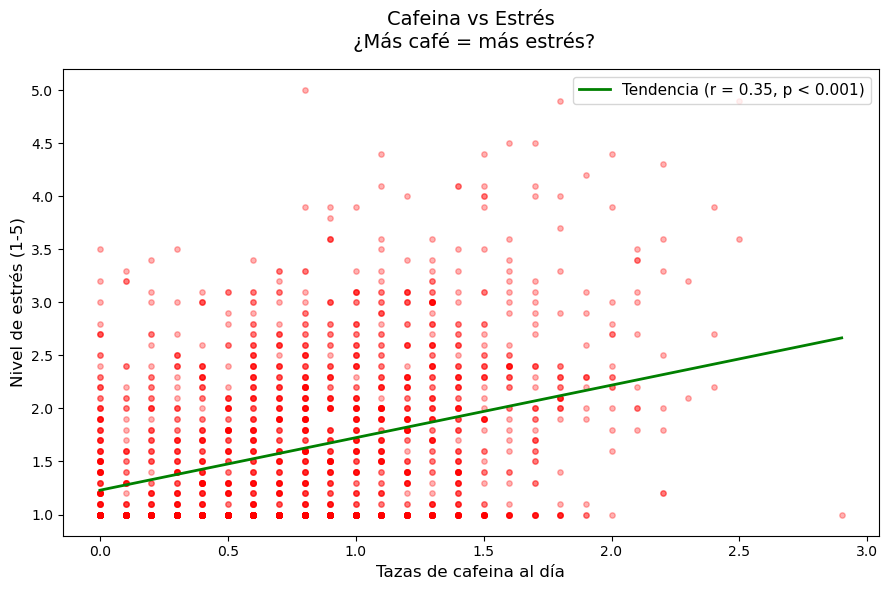

In [18]:
#Visualizacion: Scatter

fig, ax = plt.subplots(figsize=(9,6)) #Crar figura y ejes

ax.scatter(
    df['Caffeine_Intake_Cups'],
    df['Stress_Level'],
    alpha=0.3,
    s=15,
    color="red"
)

m, b = np.polyfit(df['Caffeine_Intake_Cups'], df['Stress_Level'], deg=1)

x_linea = np.linspace(df['Caffeine_Intake_Cups'].min(), df['Caffeine_Intake_Cups'].max(), 200)

y_linea = m * x_linea + b #y = mx + b


ax.plot(
    x_linea, y_linea,
    color='green',
    linewidth=2,
    label=f'Tendencia (r = {r_scipy:.2f}, p < 0.001)'
)

ax.set_xlabel("Tazas de cafeina al día", fontsize= 12)
ax.set_ylabel("Nivel de estrés (1-5)", fontsize= 12)
ax.set_title("Cafeina vs Estrés\n ¿Más café = más estrés?", fontsize= 14, pad=15)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()